# Apply Findings for ISCB SCS 2026

This notebook applies the findings and explores the impact and implications.

```
pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)
```

## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Determine what is still noise

In [3]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)

In [4]:
from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes

all_noise = []
all_real = []
for filename, adata in gse.objects.items():
    adata_real = adata[adata.obs["is_noise"] == 0].copy()
    adata_real.obs["cancer_type"] = adata_real.uns["cancer_type"]
    all_real.append(adata_real)

    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    adata_noise.obs["cancer_type"] = adata_noise.uns["cancer_type"]
    classify_noise_subtypes(adata_noise, pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
    })
    adata_noise.obs["still_noise"] = (
        # observation is NOT a potential biological signal
        (adata_noise.obs[["pbs-1", "pbs-2", "pbs-3"]] == 0).all(axis=1)
        & (adata_noise.obs["is_noise"] == 1)
    )
    all_noise.append(adata_noise)


In [5]:
all_real = ad.concat(all_real, join="inner")
all_real.obs_names_make_unique()
sc.pp.normalize_total(all_real)
sc.pp.log1p(all_real)

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
all_noise = ad.concat(all_noise, join="inner")
all_noise.obs_names_make_unique()
sc.pp.normalize_total(all_noise)
sc.pp.log1p(all_noise)

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 2. Do the potential biological signals form clusters?

In [7]:
pbs_only = all_noise.copy()
conditions = [
    pbs_only.obs["pbs-1"] == 1,
    pbs_only.obs["pbs-2"] == 1,
    pbs_only.obs["pbs-3"] == 1,
]
choices = ["pbs-1", "pbs-2", "pbs-3"]
pbs_only.obs["pbs"] = np.select(conditions, choices, default="none")

In [8]:
pbs_only = pbs_only[pbs_only.obs["pbs"] != "none"].copy()
pbs_only

AnnData object with n_obs × n_vars = 4714 × 33538
    obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'cancer_type', 'pbs-1', 'pbs-2', 'pbs-3', 'still_noise', 'pbs'
    uns: 'log1p'

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\silly\GitHub\signals-in-the-noise\src\signals_in_the_noise\preprocessing\gse161529.py:498: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, **default_cluster_parameters)


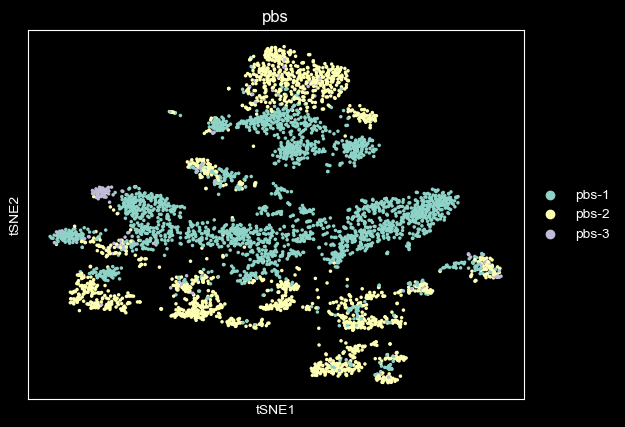

In [9]:
gse.find_clusters(pbs_only, cluster_kwargs={"resolution": 0.5})
gse.calculate_tsne(pbs_only, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(pbs_only, color=["pbs"])

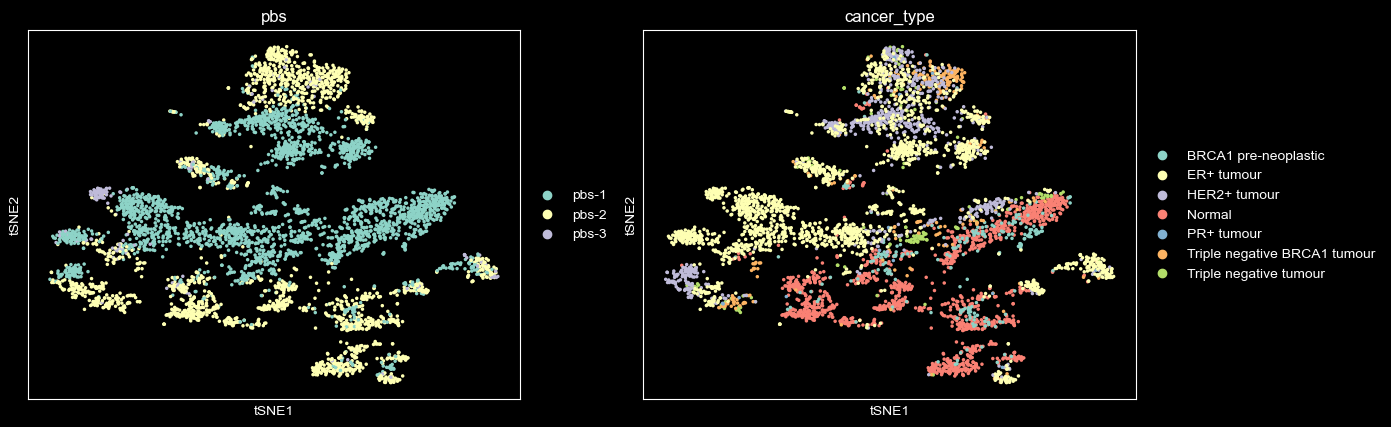

In [10]:
gse.find_clusters(pbs_only, cluster_kwargs={"resolution": 0.015})
gse.calculate_tsne(pbs_only, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(pbs_only, color=["pbs", "cancer_type"])

In [11]:
not_pbs_only = all_noise.copy()
conditions = [
    not_pbs_only.obs["pbs-1"] == 1,
    not_pbs_only.obs["pbs-2"] == 1,
    not_pbs_only.obs["pbs-3"] == 1,
]
choices = ["pbs-1", "pbs-2", "pbs-3"]
not_pbs_only.obs["pbs"] = np.select(conditions, choices, default="none")

In [12]:
not_pbs_only = pbs_only[pbs_only.obs["pbs"] != "none"].copy()
not_pbs_only

AnnData object with n_obs × n_vars = 4714 × 33538
    obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'cancer_type', 'pbs-1', 'pbs-2', 'pbs-3', 'still_noise', 'pbs', 'leiden'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'pbs_colors', 'cancer_type_colors'
    obsm: 'X_pca', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [13]:
# gse.find_clusters(not_pbs_only, cluster_kwargs={"resolution": 0.015})
# gse.calculate_tsne(not_pbs_only, tsne_kwargs={"n_jobs": 3})
# gse.visualize_tsne(not_pbs_only, color=["cancer_type"])

### 1.1. Dig into the PBS

In [14]:
pbs_only.obs["cancer_type"].unique()

['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour']
Categories (7, object): ['BRCA1 pre-neoplastic', 'ER+ tumour', 'HER2+ tumour', 'Normal', 'PR+ tumour', 'Triple negative BRCA1 tumour', 'Triple negative tumour']

In [15]:
is_pbs_1 = pbs_only.obs["pbs"] == "pbs-1"
is_normal = pbs_only.obs["cancer_type"] == "Normal"
conditions = [
    is_pbs_1 & is_normal,
    is_pbs_1 & ~is_normal,
    ~is_pbs_1 & is_normal,
]
choices = ["both", "pbs-1 only", "normal only"]
pbs_only.obs["pbs_normal"] = np.select(conditions, choices, default="neither")

In [16]:
palette = {
    "both":        "#000000",
    "pbs-1 only":  "#D55E00",
    "normal only": "#0072B2",
    "neither":     "#009E73",
}
# gse.visualize_tsne(
#     pbs_only,
#     color=["pbs_normal"],
#     plot_kwargs={"palette": palette}
# )

In [17]:
pbs_only.obs["cancer_type"].value_counts()

cancer_type
ER+ tumour                      1886
Normal                          1427
HER2+ tumour                     736
Triple negative BRCA1 tumour     258
BRCA1 pre-neoplastic             228
Triple negative tumour           164
PR+ tumour                        15
Name: count, dtype: int64

In [18]:
is_pbs_2 = pbs_only.obs["pbs"] == "pbs-2"
is_normal = pbs_only.obs["cancer_type"] == "Normal"
conditions = [
    is_pbs_2 & is_normal,
    is_pbs_2 & ~is_normal,
    ~is_pbs_2 & is_normal,
]
choices = ["both", "pbs-2 only", "normal only"]
pbs_only.obs["pbs_normal"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_normal"])

In [19]:
is_pbs_3 = pbs_only.obs["pbs"] == "pbs-3"
is_normal = pbs_only.obs["cancer_type"] == "Normal"
conditions = [
    is_pbs_3 & is_normal,
    is_pbs_3 & ~is_normal,
    ~is_pbs_3 & is_normal,
]
choices = ["both", "pbs-3 only", "normal only"]
pbs_only.obs["pbs_normal"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_normal"])

In [20]:
is_pbs_1 = pbs_only.obs["pbs"] == "pbs-1"
is_cancer = pbs_only.obs["cancer_type"] == "ER+ tumour"
conditions = [
    is_pbs_1 & is_cancer,
    is_pbs_1 & ~is_cancer,
    ~is_pbs_1 & is_cancer,
]
choices = ["both", "pbs-1 only", "cancer only"]
pbs_only.obs["pbs_cancer"] = np.select(conditions, choices, default="neither")

In [21]:
palette = {
    "both":        "#000000",
    "pbs-1 only":  "#D55E00",
    "cancer only": "#0072B2",
    "neither":     "#CCCCCC",
}
# gse.visualize_tsne(pbs_only, color=["pbs_cancer"], plot_kwargs={"palette": palette})

In [22]:
is_pbs_2 = pbs_only.obs["pbs"] == "pbs-2"
is_cancer = pbs_only.obs["cancer_type"] == "ER+ tumour"
conditions = [
    is_pbs_2 & is_cancer,
    is_pbs_2 & ~is_cancer,
    ~is_pbs_2 & is_cancer,
]
choices = ["both", "pbs-2 only", "cancer only"]
pbs_only.obs["pbs_cancer"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_cancer"])

In [23]:
is_pbs_3 = pbs_only.obs["pbs"] == "pbs-3"
is_cancer = pbs_only.obs["cancer_type"] == "ER+ tumour"
conditions = [
    is_pbs_3 & is_cancer,
    is_pbs_3 & ~is_cancer,
    ~is_pbs_3 & is_cancer,
]
choices = ["both", "pbs-3 only", "cancer only"]
pbs_only.obs["pbs_cancer"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_cancer"])

In [24]:
is_pbs_1 = pbs_only.obs["pbs"] == "pbs-1"
is_cancer = pbs_only.obs["cancer_type"] == "Triple negative BRCA1 tumour"
conditions = [
    is_pbs_1 & is_cancer,
    is_pbs_1 & ~is_cancer,
    ~is_pbs_1 & is_cancer,
]
choices = ["both", "pbs-1 only", "cancer only"]
pbs_only.obs["pbs_cancer"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_cancer"])

In [25]:
is_pbs_2 = pbs_only.obs["pbs"] == "pbs-2"
is_cancer = pbs_only.obs["cancer_type"] == "Triple negative BRCA1 tumour"
conditions = [
    is_pbs_2 & is_cancer,
    is_pbs_2 & ~is_cancer,
    ~is_pbs_2 & is_cancer,
]
choices = ["both", "pbs-2 only", "cancer only"]
pbs_only.obs["pbs_cancer"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_cancer"])

In [26]:
is_pbs_3 = pbs_only.obs["pbs"] == "pbs-3"
is_cancer = pbs_only.obs["cancer_type"] == "Triple negative BRCA1 tumour"
conditions = [
    is_pbs_3 & is_cancer,
    is_pbs_3 & ~is_cancer,
    ~is_pbs_3 & is_cancer,
]
choices = ["both", "pbs-3 only", "cancer only"]
pbs_only.obs["pbs_cancer"] = np.select(conditions, choices, default="neither")
# gse.visualize_tsne(pbs_only, color=["pbs_cancer"])

## 2. Gene signature expression analysis

In [27]:
# -- data set up --
from signals_in_the_noise.config import get_resources_path
from signals_in_the_noise.io.gmt import combine_gmt_files

pathway_to_gmt = {
    'ctrl 1': 'HALLMARK_APOPTOSIS.v2025.1.Hs.gmt',
    'ctrl 2': 'HALLMARK_PROTEIN_SECRETION.v2025.1.Hs.gmt',
    'ctrl 3': 'HALLMARK_GLYCOLYSIS.v2025.1.Hs.gmt',
    'ddr': 'HALLMARK_DNA_REPAIR.v2025.1.Hs.gmt',
    'e2f': 'HALLMARK_E2F_TARGETS.v2025.1.Hs.gmt',
    'g2m': 'HALLMARK_G2M_CHECKPOINT.v2025.1.Hs.gmt',
    'upr': 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE.v2025.1.Hs.gmt',
}

combined_pathway_path = get_resources_path(
    "/".join([gse.STUDY_ID, 'gene_set_enrichment_analysis', 'combined_gene_sets.gmt'])
)
input_paths = [
    get_resources_path("/".join([gse.STUDY_ID, 'gene_set_enrichment_analysis', f]))
    for f in pathway_to_gmt.values()
]
combine_gmt_files(input_paths, combined_pathway_path)

WindowsPath('C:/Users/silly/GitHub/signals-in-the-noise/resources/GSE161529/gene_set_enrichment_analysis/combined_gene_sets.gmt')

In [28]:
# Rebuild clean PBS subset from unscaled all_noise
pbs_only_gsea = all_noise.copy()
conditions = [
    pbs_only_gsea.obs["pbs-1"] == 1,
    pbs_only_gsea.obs["pbs-2"] == 1,
    pbs_only_gsea.obs["pbs-3"] == 1,
]
choices = ["pbs-1", "pbs-2", "pbs-3"]
pbs_only_gsea.obs["pbs"] = np.select(conditions, choices, default="none")
pbs_only_gsea = pbs_only_gsea[pbs_only_gsea.obs["pbs"] != "none"].copy()
if not sp.issparse(pbs_only_gsea.X):
    pbs_only_gsea.X = sp.csr_matrix(pbs_only_gsea.X)

# Then use pbs_only_gsea everywhere pbs_only appeared in the GSEA concat
pbs_vs_real = ad.concat([all_real, pbs_only_gsea], join='inner')
pbs_vs_real.obs['is_noise'] = pbs_vs_real.obs['is_noise'].map({1: 'noise', 0: 'real'})

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [29]:
sc.pp.highly_variable_genes(pbs_vs_real)     # compute HVG flags
pbs_vs_real = pbs_vs_real[:, pbs_vs_real.var['highly_variable']].copy()  # filter to HVGs
sc.tl.rank_genes_groups(
    pbs_vs_real,
    groupby='is_noise',
    groups=['noise'],
    reference='real',
    method='wilcoxon',
    n_genes=pbs_vs_real.shape[1],            # now shape[1] is ~2000 not ~33000
)

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [30]:
de_results = pbs_vs_real.uns['rank_genes_groups']

de_df = pd.DataFrame({
    'gene': de_results['names']['noise'],
    'score': de_results['logfoldchanges']['noise'],
})
de_df = de_df.dropna().drop_duplicates(subset='gene')
de_df = de_df.sort_values('score', ascending=False)

ranked_genes_df = de_df.set_index('gene')['score']

gsea_res = gp.prerank(
    rnk=ranked_genes_df,
    gene_sets=str(combined_pathway_path),
    min_size=3,
    permutation_num=1000,
    outdir=None,
    seed=gse.random_seed,
    verbose=True,
)

2026-06-13 18:28:59,851 [INFO] Parsing data files for GSEA.............................
2026-06-13 18:28:59,856 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=3
2026-06-13 18:28:59,857 [INFO] 0007 gene_sets used for further statistical testing.....
2026-06-13 18:28:59,857 [INFO] Start to run GSEA...Might take a while..................
2026-06-13 18:28:59,952 [INFO] Congratulations. GSEApy runs successfully................



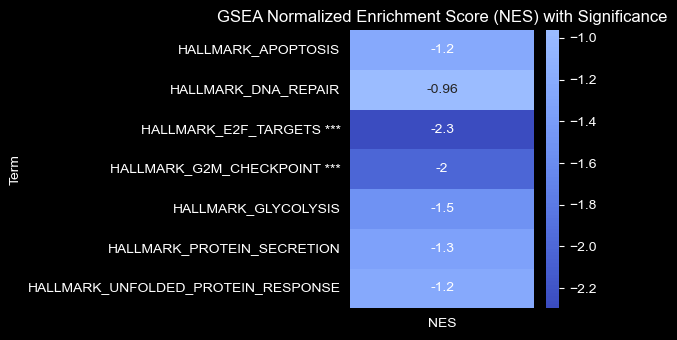

In [31]:
from signals_in_the_noise.utils.visualization import plot_gsea_nes_heatmap

plot_gsea_nes_heatmap(gsea_res.res2d)
plt.tight_layout()
plt.show()

In [32]:
all_noise, all_real

(AnnData object with n_obs × n_vars = 87044 × 33538
     obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'cancer_type', 'pbs-1', 'pbs-2', 'pbs-3', 'still_noise'
     uns: 'log1p',
 AnnData object with n_obs × n_vars = 340980 × 33538
     obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise',

In [33]:
# Rebuild clean PBS subset from unscaled all_noise
not_pbs_only_gsea = all_noise.copy()
conditions = [
    not_pbs_only_gsea.obs["pbs-1"] == 1,
    not_pbs_only_gsea.obs["pbs-2"] == 1,
    not_pbs_only_gsea.obs["pbs-3"] == 1,
]
choices = ["pbs-1", "pbs-2", "pbs-3"]
not_pbs_only_gsea.obs["pbs"] = np.select(conditions, choices, default="none")
not_pbs_only_gsea = not_pbs_only_gsea[not_pbs_only_gsea.obs["pbs"] == "none"].copy()
if not sp.issparse(not_pbs_only_gsea.X):
    not_pbs_only_gsea.X = sp.csr_matrix(not_pbs_only_gsea.X)
    
not_pbs_vs_real = ad.concat([all_real, not_pbs_only_gsea], join='inner')
not_pbs_vs_real.obs['is_noise'] = not_pbs_vs_real.obs['is_noise'].map({1: 'noise', 0: 'real'})

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [34]:
sc.pp.highly_variable_genes(not_pbs_vs_real)     # compute HVG flags
not_pbs_vs_real = not_pbs_vs_real[:, not_pbs_vs_real.var['highly_variable']].copy()  # filter to HVGs
sc.tl.rank_genes_groups(
    not_pbs_vs_real,
    groupby='is_noise',
    groups=['noise'],
    reference='real',
    method='wilcoxon',
    n_genes=not_pbs_vs_real.shape[1],            # now shape[1] is ~2000 not ~33000
)

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [35]:
de_results = not_pbs_vs_real.uns['rank_genes_groups']

de_df = pd.DataFrame({
    'gene': de_results['names']['noise'],
    'score': de_results['logfoldchanges']['noise'],
})
de_df = de_df.dropna().drop_duplicates(subset='gene')
de_df = de_df.sort_values('score', ascending=False)

ranked_genes_df = de_df.set_index('gene')['score']

gsea_res = gp.prerank(
    rnk=ranked_genes_df,
    gene_sets=str(combined_pathway_path),
    min_size=3,
    permutation_num=1000,
    outdir=None,
    seed=gse.random_seed,
    verbose=True,
)

2026-06-13 18:29:40,507 [WARNING] Duplicated values found in preranked stats: 0.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-13 18:29:40,507 [INFO] Parsing data files for GSEA.............................
2026-06-13 18:29:40,514 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=3
2026-06-13 18:29:40,514 [INFO] 0007 gene_sets used for further statistical testing.....
2026-06-13 18:29:40,514 [INFO] Start to run GSEA...Might take a while..................
2026-06-13 18:29:40,613 [INFO] Congratulations. GSEApy runs successfully................



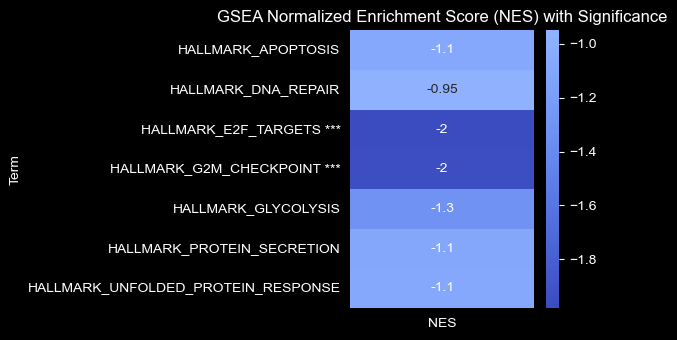

In [36]:
plot_gsea_nes_heatmap(gsea_res.res2d)
plt.tight_layout()
plt.show()

## 3. Pathway analysis

In [37]:
# # -- Rebuild PBS subset from log-normalized, unscaled all_noise --
# pbs_heatmap = all_noise.copy()
# conditions = [
#     pbs_heatmap.obs["pbs-1"] == 1,
#     pbs_heatmap.obs["pbs-2"] == 1,
#     pbs_heatmap.obs["pbs-3"] == 1,
# ]
# choices = ["pbs-1", "pbs-2", "pbs-3"]
# pbs_heatmap.obs["pbs"] = np.select(conditions, choices, default="none")
# pbs_heatmap = pbs_heatmap[pbs_heatmap.obs["pbs"] != "none"].copy()
#
# # Capture log-normalized state as .raw (required for sc.tl.score_genes use_raw=True)
# pbs_heatmap.raw = pbs_heatmap.copy()
#
# # Add specimen_id
# pbs_heatmap.obs["specimen_id"] = (
#     pbs_heatmap.obs["adata-filename"].str.replace(".h5ad", "", regex=False)
# )

In [38]:
# sc.tl.score_genes(
#     pbs_heatmap,
#     gene_list=gse.tumor_proliferation_genes,
#     score_name="tp_score",
#     use_raw=True,
# )
# sc.tl.score_genes(
#     pbs_heatmap,
#     gene_list=gse.chemo_resistance_genes,
#     score_name="cr_score",
#     use_raw=True,
# )

In [39]:
# from signals_in_the_noise.utils.visualization import plot_score_heatmap
#
# # Sort cells by PBS subtype, then by specimen within subtype
# sort_idx = pbs_heatmap.obs.sort_values(["pbs", "specimen_id"]).index
# pbs_sorted = pbs_heatmap[sort_idx].copy()
#
# fig, ax = plt.subplots(figsize=(60, 4))
# plot_score_heatmap(
#     pbs_sorted,
#     score_columns=["tp_score", "cr_score"],
#     title="Pathway Scores in PBS Cells (sorted by subtype)",
#     ax=ax,
# )
# plt.show()

In [40]:
# from signals_in_the_noise.io.gmt import load_gmt
# from signals_in_the_noise.utils.visualization import plot_pathway_heatmap
#
# pathway_to_genes = {}
# for key, gmt_file in pathway_to_gmt.items():
#     gmt_path = get_resources_path(f"{gse.STUDY_ID}/gene_set_enrichment_analysis/{gmt_file}")
#     pathway_name = gmt_path.stem.split(".")[0]
#     pathway_to_genes[pathway_name] = load_gmt(gmt_path)
#
# for pathway_name, pathway_genes in pathway_to_genes.items():
#     plot_pathway_heatmap(pbs_sorted, pathway_name, pathway_genes)
#     plt.show()

In [41]:
# from signals_in_the_noise.config import get_data_path
# from signals_in_the_noise.utils.visualization import plot_pathway_heatmap, get_figure_axes
#
# figures_dir = get_data_path("GSE161529/figures")
# figures_dir.mkdir(exist_ok=True)
#
# subtypes = ["pbs-1", "pbs-2", "pbs-3"]
# n_panels_per_subtype = 2  # matches plot_pathway_heatmap default
#
# for pathway_name, pathway_genes in pathway_to_genes.items():
#     safe_name = pathway_name.lower()
#
#     # -- all PBS signals together (06-a style) --
#     all_axes = plot_pathway_heatmap(pbs_heatmap, pathway_name, pathway_genes)
#     fig_all = all_axes[0].get_figure()
#     plt.tight_layout()
#     fig_all.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-all.png", bbox_inches="tight", dpi=150)
#     plt.show()
#
#     # -- separated by subtype --
#     fig_sub, axes = get_figure_axes(
#         n_plots=len(subtypes) * n_panels_per_subtype,
#         num_cols=len(subtypes),
#         subplot_size=(20, 5),
#         super_title=f"Mean Expression per Specimen — {pathway_name}",
#     )
#     for col, subtype in enumerate(subtypes):
#         pbs_sub = pbs_heatmap[pbs_heatmap.obs["pbs"] == subtype].copy()
#         subtype_axes = [axes[col + len(subtypes) * row] for row in range(n_panels_per_subtype)]
#         subtype_axes[0].set_title(subtype)
#         plot_pathway_heatmap(
#             pbs_sub,
#             pathway_name,
#             pathway_genes,
#             n_panels=n_panels_per_subtype,
#             axes=subtype_axes,
#         )
#     plt.tight_layout()
#     fig_sub.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-by-subtype.png", bbox_inches="tight", dpi=150)
#     plt.show()

In [42]:
# pathway_to_genes.keys()

In [43]:
# subtypes = ["pbs-1", "pbs-2", "pbs-3"]
# n_panels_per_subtype = 5  # matches plot_pathway_heatmap default
#
# all_pathway_genes = []
# for genes in pathway_to_genes.values():
#     all_pathway_genes.extend(genes)
#
# safe_name = "all"
# sc.tl.score_genes(
#     pbs_heatmap,
#     gene_list=all_pathway_genes,
#     score_name="score",
#     use_raw=True,
# )
# # -- all PBS signals together (06-a style) --
# all_axes = plot_pathway_heatmap(pbs_heatmap, "All Pathway Genes of Interest", all_pathway_genes, n_panels=5)
# fig_all = all_axes[0].get_figure()
# plt.tight_layout()
# fig_all.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-all.png", bbox_inches="tight", dpi=300)
# plt.show()
#
# # # -- separated by subtype --
# # fig_sub, axes = get_figure_axes(
# #     n_plots=len(subtypes) * n_panels_per_subtype,
# #     num_cols=len(subtypes),
# #     subplot_size=(20, 5),
# #     super_title=f"Mean Expression per Specimen — {pathway_name}",
# # )
# # for col, subtype in enumerate(subtypes):
# #     pbs_sub = pbs_heatmap[pbs_heatmap.obs["pbs"] == subtype].copy()
# #     subtype_axes = [axes[col + len(subtypes) * row] for row in range(n_panels_per_subtype)]
# #     subtype_axes[0].set_title(subtype)
# #     plot_pathway_heatmap(
# #         pbs_sub,
# #         pathway_name,
# #         pathway_genes,
# #         n_panels=n_panels_per_subtype,
# #         axes=subtype_axes,
# #     )
# # plt.tight_layout()
# # fig_sub.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-by-subtype.png", bbox_inches="tight", dpi=150)
# plt.show()

In [44]:
# nk_marker_genes = [
#     "FCGR3A",
#     "PRF1",
#     "FGFBP2",
#     "GZMH",
#     "ETS1",
#     "NR4A1",
#     "NR4A2",
#     "DUSP1",
#     "DUSP2",
#     "FOS",
#     "JUN",
#     "FCGR3A",
#     "PRF1",
#     "FGFBP2",
#     "GZMA",
#     "GZMB",
#     "CXCF1",
#     "SPON2",
#     "CX3CR1",
#     "S1PR5",
#     "GZMK",
#     "SELL",
#     "IL7R",
#     "LTB",
#     "ISG15",
#     "IFI6",
#     "IFIT3",
#     "IFI44L",
#     "CCL5",
#     "HLA-DRB1",
#     "KLRC1",
#     "CD74",
#     "MYADM",
#     "HSPE1",
# ]
#
# list(set(nk_marker_genes));

In [45]:
# safe_name = "nk"
# sc.tl.score_genes(
#     pbs_heatmap,
#     gene_list=nk_marker_genes,
#     score_name="score",
#     use_raw=True,
# )
# # -- all PBS signals together (06-a style) --
# all_axes = plot_pathway_heatmap(pbs_heatmap, "Marker Genes for Natural Killer (NK) Cells", nk_marker_genes, n_panels=1)
# fig_all = all_axes[0].get_figure()
# plt.tight_layout()
# fig_all.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-all.png", bbox_inches="tight", dpi=150)
# plt.show()

In [46]:
# up_rnk_genes = [
#     "ABCA1",
#     "ALOX12",
#     "CALD1",
#     "CAVIN2",
#     "CCL4",
#     "CLU",
#     "CMKLR1",
#     "CR2",
#     "CX3CR1",
#     "DTX1",
#     "DUSP1",
#     "F5",
#     "FAM81A",
#     "FOS",
#     "FOSB",
#     "GAS2L1",
#     "GFRA2",
#     "GP6",
#     "HEATR9",
#     "HES1",
#     "ITGAX",
#     "JUN",
#     "KLRG1",
#     "LTBP1",
#     "MID1",
#     "MPIG6B",
#     "NHSL2",
#     "NR4A1",
#     "NR4A2",
#     "NR4A3",
#     "NYLK",
#     "PARVB",
#     "PLXNA4",
#     "RASGRP2",
#     "RHPN1",
#     "SCD",
#     "SLC6A4",
#     "THBS1",
#     "TMTC1",
#     "TNFAIP3",
#     "TUBB1",
#     "VWF",
#     "XDH",
# ]
# safe_name = "up-reg-nk"
# sc.tl.score_genes(
#     pbs_heatmap,
#     gene_list=up_rnk_genes,
#     score_name="score",
#     use_raw=True,
# )
# # -- all PBS signals together (06-a style) --
# all_axes = plot_pathway_heatmap(pbs_heatmap, "Upregulated rNK Genes", up_rnk_genes, n_panels=1)
# fig_all = all_axes[0].get_figure()
# plt.tight_layout()
# fig_all.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-all-up.png", bbox_inches="tight", dpi=150)
# plt.show()

In [47]:
# down_rnk_genes = [
#     "AHRR",
#     "ALDH1B2",
#     "ASB2",
#     "ASNS",
#     "ATF5",
#     "AVIL",
#     "BCAT1",
#     "CARS1",
#     "CDH1",
#     "CDKN1A",
#     "CISH",
#     "CLBA1",
#     "COX6A2",
#     "CXCR6",
#     "EXYL1",
#     "GPT2",
#     "HMOX1",
#     "HPGDS",
#     "ISG20",
#     "ITGA1",
#     "LGALS3",
#     "LHFPL2",
#     "ME1",
#     "MTHFD2",
#     "NEK6",
#     "NQO1",
#     "OSBPL1A",
#     "OSGIN1",
#     "PACSIN1",
#     "PMEPA1",
#     "PPP2R2C",
#     "PYCR1",
#     "SCN3B",
#     "SH3PXD2B",
#     "SLC1A4",
#     "SLC6A9",
#     "SCL7A3",
#     "SLC7A5",
#     "SNORA23",
#     "STTR2",
#     "TBC1D16",
#     "TRIB3",
#     "ZNF503"
# ]
# safe_name = "down-reg-nk"
# sc.tl.score_genes(
#     pbs_heatmap,
#     gene_list=down_rnk_genes,
#     score_name="score",
#     use_raw=True,
# )
# # -- all PBS signals together (06-a style) --
# all_axes = plot_pathway_heatmap(pbs_heatmap, "Downregulated rNK Genes", down_rnk_genes, n_panels=1)
# fig_all = all_axes[0].get_figure()
# plt.tight_layout()
# fig_all.savefig(figures_dir / f"09-pbs-pathway-{safe_name}-all-down.png", bbox_inches="tight", dpi=150)
# plt.show()